In [ ]:
import os, zipfile
import numpy as np
import tensorflow as tf
import cv2
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter

from google.colab import drive
drive.mount("/content/drive")

zip_path = "/content/drive/MyDrive/Parkinson's Dataset Final.zip"
extract_path = "/content/dataset"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

BASE = "/content/dataset/Parkinson's Dataset Final"
print("Extracted:", os.listdir(BASE))

Mounted at /content/drive
Extracted: ['New hand pd Dataset', 'Hand Pd']


In [ ]:
!pip -q install imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 12.1 MB/s eta 0:00:00


In [ ]:
import imagehash
from PIL import Image
from collections import defaultdict

In [ ]:
Raw total: 0
Distribution: Counter()

NewHandPD total: 512
Healthy: 233
Parkinson: 279


Removing near duplicates NewHandPD: 100%|██████████| 467/467 [00:02<00:00, 231.72it/s]


CLEAN NEWHANDPD
Images: 369
Healthy: 191
Parkinson: 178


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from collections import Counter

paths = np.array(clean_paths_newhandpd)
labels = np.array(clean_labels_newhandpd)

In [ ]:
# 80% train, 20% temp
train_paths, temp_paths, y_train, y_temp = train_test_split(
    paths,
    labels,
    test_size=0.20,
    stratify=labels,
    random_state=42
)

# 10% val, 10% test
val_paths, test_paths, y_val, y_test = train_test_split(
    temp_paths,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", Counter(y_train))
print("Val:", Counter(y_val))
print("Test:", Counter(y_test))

Train: Counter({np.int64(0): 153, np.int64(1): 142})
Val: Counter({np.int64(0): 19, np.int64(1): 18})
Test: Counter({np.int64(0): 19, np.int64(1): 18})


In [ ]:
print("Train-Val overlap:", len(set(train_paths) & set(val_paths)))
print("Train-Test overlap:", len(set(train_paths) & set(test_paths)))
print("Val-Test overlap:", len(set(val_paths) & set(test_paths)))

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 16

import cv2
import tensorflow as tf
import numpy as np

def preprocess(path):
    path = path.numpy().decode()
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # CLAHE only
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)

    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=-1)

    return img

def tf_preprocess(path, label):
    img = tf.py_function(preprocess, [path], tf.float32)
    img.set_shape((IMG_SIZE, IMG_SIZE, 1))
    label = tf.cast(label, tf.float32)
    return img, label

In [ ]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomContrast(0.1),
], name="augmentation")

In [ ]:
def make_train_ds(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.shuffle(1000)
    ds = ds.map(tf_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

def make_eval_ds(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(tf_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_train_ds(train_paths, y_train)
val_ds   = make_eval_ds(val_paths, y_val)
test_ds  = make_eval_ds(test_paths, y_test)

print("tf.data pipeline ready for NewHandPD")

tf.data pipeline ready for NewHandPD


In [ ]:
from collections import Counter

def check_distribution(dataset, name):
    counts = {0: 0, 1: 0}
    for _, labels in dataset:
        labels_np = labels.numpy()
        counts[0] += np.sum(labels_np == 0)
        counts[1] += np.sum(labels_np == 1)
    print(f"{name} distribution:", counts)

check_distribution(train_ds, "Train")
check_distribution(val_ds, "Val")
check_distribution(test_ds, "Test")

Train distribution: {0: np.int64(153), 1: np.int64(142)}
Val distribution: {0: np.int64(19), 1: np.int64(18)}
Test distribution: {0: np.int64(19), 1: np.int64(18)}


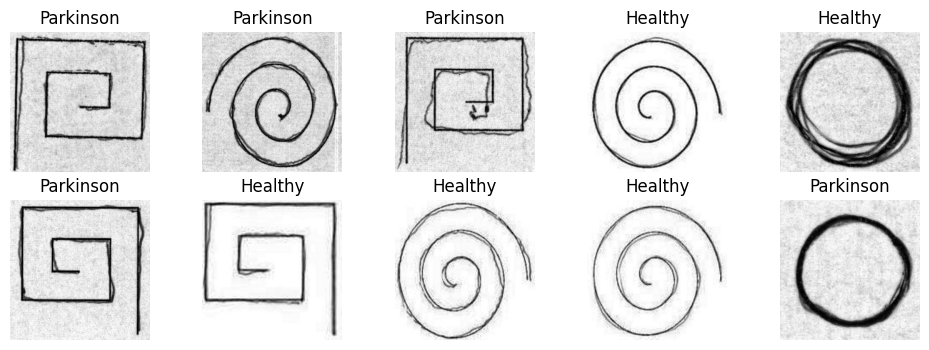

In [ ]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    images = images.numpy()
    labels = labels.numpy()

    plt.figure(figsize=(12,4))
    for i in range(10):
        plt.subplot(2,5,i+1)
        plt.imshow(images[i].squeeze(), cmap="gray")
        plt.title("Healthy" if labels[i]==0 else "Parkinson")
        plt.axis("off")
    plt.show()

In [ ]:
for imgs, _ in train_ds.take(1):
    print("Min:", imgs.numpy().min())
    print("Max:", imgs.numpy().max())

Min: 0.0
Max: 1.0284847


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = {int(c): float(w) for c, w in zip(classes, weights)}
print(class_weight_dict)

{0: 0.9640522875816994, 1: 1.0387323943661972}


In [ ]:

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow import keras

In [ ]:
IMG_SIZE = 224
PATCH_SIZE = 16
DIMS = [526, 512, 256, 128, 64, 32, 16]

NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2

In [ ]:
class PatchEmbedding(layers.Layer):
    def __init__(self, patch_size, embed_dim):
        super().__init__()
        self.embed_dim = embed_dim
        self.proj = layers.Conv2D(
            filters=embed_dim,
            kernel_size=patch_size,
            strides=patch_size,
            padding="valid"
        )

    def call(self, x):
        x = self.proj(x)  # (B,14,14,embed_dim)
        x = tf.reshape(x, [tf.shape(x)[0], -1, self.embed_dim])
        return x

In [ ]:
class AddCLSPositional(layers.Layer):
    def __init__(self, num_patches, embed_dim):
        super().__init__()
        self.num_patches = num_patches
        self.embed_dim = embed_dim

    def build(self, input_shape):
        self.cls_token = self.add_weight(
            shape=(1, 1, self.embed_dim),
            initializer="random_normal",
            trainable=True
        )
        self.pos_embed = self.add_weight(
            shape=(1, self.num_patches + 1, self.embed_dim),
            initializer="random_normal",
            trainable=True
        )

    def call(self, x):
        batch = tf.shape(x)[0]
        cls = tf.repeat(self.cls_token, repeats=batch, axis=0)
        x = tf.concat([cls, x], axis=1)
        return x + self.pos_embed

In [ ]:
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim):
        super().__init__()
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(
            num_heads=4,
            key_dim=max(embed_dim // 4, 1)
        )
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = keras.Sequential([
            layers.Dense(embed_dim * 2, activation="gelu"),
            layers.Dense(embed_dim)
        ])

    def call(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

In [ ]:
class Projection(layers.Layer):
    def __init__(self, new_dim):
        super().__init__()
        self.dense = layers.Dense(new_dim)

    def call(self, x):
        return self.dense(x)

In [ ]:
def build_hierarchical_vit():

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

    x = PatchEmbedding(PATCH_SIZE, DIMS[0])(inputs)
    x = AddCLSPositional(NUM_PATCHES, DIMS[0])(x)

    for i in range(len(DIMS)):
        x = TransformerBlock(DIMS[i])(x)

        if i < len(DIMS) - 1:
            x = Projection(DIMS[i + 1])(x)

    x = layers.LayerNormalization(epsilon=1e-6)(x)

    cls = x[:, 0]

    x = layers.Dense(8, activation="relu")(cls)
    x = layers.Dense(4, activation="relu")(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)
    return model


vit_model = build_hierarchical_vit()
vit_model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embedding                 │ (None, None, 526)      │       135,182 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_cls_positional              │ (None, 197, 526)       │       104,148 │
│ (AddCLSPositional)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 197, 526)       │     2,214,980 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection (Projection)         │ (None, 197, 512)       │       269,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 197, 512)       │     2,102,784 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_1 (Projection)       │ (None, 197, 256)       │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 197, 256)       │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_2 (Projection)       │ (None, 197, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 197, 128)       │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_3 (Projection)       │ (None, 197, 64)        │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ (None, 197, 64)        │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_4 (Projection)       │ (None, 197, 32)        │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_5             │ (None, 197, 32)        │         8,544 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_5 (Projection)       │ (None, 197, 16)        │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_6             │ (None, 197, 16)        │         2,224 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_14          │ (None, 197, 16)        │            32 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item (GetItem)              │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 4)              │            3

 Total params: 5,706,039 (21.77 MB)

 Trainable params: 5,706,039 (21.77 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
vit_model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-4,
        weight_decay=1e-4
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [ ]:
history = vit_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
)

Epoch 1/60
19/19 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.4548 - auc: 0.5000 - loss: 0.6932 - val_accuracy: 0.4865 - val_auc: 0.5000 - val_loss: 0.6932
Epoch 2/60
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - accuracy: 0.4380 - auc: 0.5000 - loss: 0.6932 - val_accuracy: 0.4865 - val_auc: 0.5000 - val_loss: 0.6932
Epoch 3/60
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.4839 - auc: 0.5000 - loss: 0.6932 - val_accuracy: 0.4865 - val_auc: 0.5000 - val_loss: 0.6932
Epoch 4/60
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step - accuracy: 0.4922 - auc: 0.5000 - loss: 0.6931 - val_accuracy: 0.4865 - val_auc: 0.5000 - val_loss: 0.6931
Epoch 5/60
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 0.4575 - auc: 0.5000 - loss: 0.6931 - val_accuracy: 0.5135 - val_auc: 0.5000 - val_loss: 0.6931
Epoch 6/60
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.5159 - auc: 0.5000 - loss: 0.6931 - val_accuracy: 0.5135 - val_auc: 0.5000 - val_loss: 0.6931
Epoch 7/60
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 1

KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

IMG_SIZE = 224
PATCH_SIZE = 16

DIMS = [526, 256, 128, 64, 32, 16, 8, 4, 2]


class PatchEmbedding(layers.Layer):
    def __init__(self, patch_size, embed_dim):
        super().__init__()
        self.embed_dim = embed_dim
        self.proj = layers.Conv2D(
            embed_dim,
            kernel_size=patch_size,
            strides=patch_size,
            padding="valid"
        )

    def call(self, x):
        x = self.proj(x)
        x = tf.reshape(x, [tf.shape(x)[0], -1, self.embed_dim])
        return x


class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim):
        super().__init__()
        self.norm1 = layers.LayerNormalization()
        self.attn = layers.MultiHeadAttention(
            num_heads=2,
            key_dim=max(embed_dim // 2, 1)
        )
        self.norm2 = layers.LayerNormalization()
        self.mlp = keras.Sequential([
            layers.Dense(embed_dim * 2, activation="gelu"),
            layers.Dense(embed_dim)
        ])

    def call(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


class Projection(layers.Layer):
    def __init__(self, new_dim):
        super().__init__()
        self.proj = layers.Dense(new_dim)

    def call(self, x):
        return self.proj(x)


def build_custom_hierarchical():

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

    x = PatchEmbedding(PATCH_SIZE, DIMS[0])(inputs)

    for i in range(len(DIMS)):

        x = TransformerBlock(DIMS[i])(x)

        if i < len(DIMS) - 1:
            x = Projection(DIMS[i + 1])(x)

    x = layers.LayerNormalization()(x)

    x = layers.GlobalAveragePooling1D()(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)
    return model


model = build_custom_hierarchical()
model.summary()

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embedding_1               │ (None, None, 526)      │       135,182 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_7             │ (None, None, 526)      │     2,219,194 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_6 (Projection)       │ (None, None, 256)      │       134,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_8             │ (None, None, 256)      │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_7 (Projection)       │ (None, None, 128)      │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_9             │ (None, None, 128)      │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_8 (Projection)       │ (None, None, 64)       │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_10            │ (None, None, 64)       │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_9 (Projection)       │ (None, None, 32)       │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_11            │ (None, None, 32)       │         8,544 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_10 (Projection)      │ (None, None, 16)       │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_12            │ (None, None, 16)       │         2,224 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_11 (Projection)      │ (None, None, 8)        │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_13            │ (None, None, 8)        │           600 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_12 (Projection)      │ (None, None, 4)        │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_14            │ (None, None, 4)        │           172 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_13 (Projection)      │ (None, None, 2)        │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_15            │ (None, None, 2)        │            54 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_33          │ (None, None, 2)        │             

 Total params: 3,237,887 (12.35 MB)

 Trainable params: 3,237,887 (12.35 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.4994 - auc: 0.5042 - loss: 0.9000 - val_accuracy: 0.4865 - val_auc: 0.5000 - val_loss: 0.9151
Epoch 2/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 176ms/step - accuracy: 0.4666 - auc: 0.4858 - loss: 0.9405 - val_accuracy: 0.4865 - val_auc: 0.5000 - val_loss: 0.9121
Epoch 3/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.4824 - auc: 0.4972 - loss: 0.9169 - val_accuracy: 0.4865 - val_auc: 0.5000 - val_loss: 0.9092
Epoch 4/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - accuracy: 0.4757 - auc: 0.5000 - loss: 0.9226 - val_accuracy: 0.4865 - val_auc: 0.5000 - val_loss: 0.9063
Epoch 5/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - accuracy: 0.4970 - auc: 0.5104 - loss: 0.8920 - val_accuracy: 0.4865 - val_auc: 0.5000 - val_loss: 0.9034
